In [180]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise
from scipy.signal import convolve2d
from scipy.ndimage import median_filter

In [181]:
def visualize_results(original, noise, noisy_img, median_filtered, linear_filtered, 
                     noise_title, median_title, linear_title):
    """Визуализация исходного, зашумленного и отфильтрованных изображений"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Первая строка
    axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title("Исходное изображение")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(noise, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(noise_title)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(noisy_img, cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title("Зашумленное изображение")
    axes[0, 2].axis('off')
    
    # Вторая строка
    axes[1, 0].imshow(median_filtered, cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title(median_title)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(linear_filtered, cmap='gray', vmin=0, vmax=255)
    axes[1, 1].set_title(linear_title)
    axes[1, 1].axis('off')
    
    # Пустая ячейка для симметрии
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [182]:
def generate_chessboard():
    """Генерация шахматного поля 128x128 с значениями 96 и 160"""
    img = np.zeros((128, 128))
    
    # Создание шахматного паттерна
    img[:64, :64] = 96
    img[:64, 64:128] = 160
    img[64:128, :64] = 160
    img[64:128, 64:128] = 96

    return img

def calculate_mse(filtered_img, original_img):
    """Вычисление среднеквадратичной ошибки между изображениями"""
    mse = np.mean((filtered_img - original_img) ** 2)
    return mse

In [183]:
def analyze_gaussian_noise(chessboard, snr_ratio, mask_size):
    """Анализ аддитивного белого шума с заданным отношением сигнал/шум"""
    original_variance = np.var(chessboard)
    
    print(f"\n=== АДДИТИВНЫЙ БЕЛЫЙ ШУМ (SNR = {snr_ratio}) ===")
    print(f"Дисперсия исходного изображения: {original_variance:.2f}")

    # Генерация гауссовского шума
    noise_std = np.sqrt(original_variance / snr_ratio)
    gaussian_noise = np.random.normal(0, noise_std, chessboard.shape)
    
    # Добавление шума к изображению
    noisy_chessboard = chessboard + gaussian_noise
    noisy_chessboard = np.clip(noisy_chessboard, 0, 255).astype(np.uint8)
    
    # Создание усредняющего фильтра 3x3
    #averaging_filter = 1/9 *  np.array([[1,1,1],
    #                                    [1,1,1],
    #                                    [1,1,1]])
    averaging_filter = np.ones((mask_size, mask_size)) / (mask_size*mask_size)


    # Линейная фильтрация
    linear_filtered = convolve2d(noisy_chessboard.astype(float), averaging_filter, 
                               mode='same', boundary='symm')
    # Ограничиваем значение пикселей
    linear_filtered = np.clip(linear_filtered, 0, 255).astype(np.uint8)
    
    # Медианная фильтрация
    median_filtered = median_filter(noisy_chessboard, size=3)

    # Расчет ошибок
    mse_noisy = calculate_mse(noisy_chessboard.astype(float), chessboard.astype(float))
    mse_linear = calculate_mse(linear_filtered.astype(float), chessboard.astype(float))
    mse_median = calculate_mse(median_filtered.astype(float), chessboard.astype(float))
    
    # Коэффициенты снижения шума
    noise_reduction_linear = mse_linear / mse_noisy 
    noise_reduction_median = mse_median / mse_noisy 

    print(f"Дисперсия шума: {np.var(gaussian_noise):.2f}")
    print(f"Дисперсия зашумленного изображения: {np.var(noisy_chessboard):.2f}")
    print(f"Ср.Кв ошибка  зашумленного изображения: {mse_noisy:.2f}")
    print(f"Ср.Кв ошибка после линейной фильтрации: {mse_linear:.2f}")
    print(f"Ср.Кв ошибка после медианной фильтрации: {mse_median:.2f}")
    print(f"Коэффициент снижения шума (линейный): {noise_reduction_linear:.4f}")
    print(f"Коэффициент снижения шума (медианный): {noise_reduction_median:.4f}")

    # Визуализация результатов
    visualize_results(chessboard, gaussian_noise + 128, noisy_chessboard, 
                     median_filtered, linear_filtered, 
                     f"Белый шум (SNR={snr_ratio})", 
                     "Медианный фильтр", "Линейный фильтр")


# Фильтрация импульсного шума

In [184]:

def analyze_impulse_noise(chessboard, probability, mask_size ):
    """Анализ импульсного шума с заданной вероятностью"""
    original_variance = np.var(chessboard)
    
    print(f"\n=== ИМПУЛЬСНЫЙ ШУМ (p = {probability}) ===")
    print(f"Дисперсия исходного изображения: {original_variance:.2f}")

    # Нормализация для функции random_noise
    normalized_chessboard = chessboard / 255.0
    
    # Добавление импульсного шума
    noisy_normalized = random_noise(normalized_chessboard, mode='s&p', amount=probability)
    noisy_chessboard = (noisy_normalized * 255).astype(np.uint8)
    
    # Создание маски шума для визуализации
    noise_mask = np.zeros_like(chessboard, dtype=np.uint8) + 128
    noise_mask[noisy_chessboard == 0] = 0    # "Перец"
    noise_mask[noisy_chessboard == 255] = 255  # "Соль"
    
    # Создание усредняющего фильтра 3x3
    averaging_filter = np.ones((mask_size, mask_size)) / (mask_size*mask_size)

    # Линейная фильтрация
    linear_filtered = convolve2d(noisy_chessboard.astype(float), averaging_filter, 
                               mode='same', boundary='symm')
    linear_filtered = np.clip(linear_filtered, 0, 255).astype(np.uint8)
    
    # Медианная фильтрация
    median_filtered = median_filter(noisy_chessboard, size=mask_size)

    # Расчет ошибок
    mse_noisy = calculate_mse(noisy_chessboard.astype(float), chessboard.astype(float))
    mse_linear = calculate_mse(linear_filtered.astype(float), chessboard.astype(float))
    mse_median = calculate_mse(median_filtered.astype(float), chessboard.astype(float))
    
    # Коэффициенты снижения шума
    noise_reduction_linear = mse_linear / mse_noisy 
    noise_reduction_median = mse_median / mse_noisy

    print(f"Ср.Кв ошибка зашумленного изображения: {mse_noisy:.2f}")
    print(f"Ср.Кв ошибка после линейной фильтрации: {mse_linear:.2f}")
    print(f"Ср.Кв ошибка после медианной фильтрации: {mse_median:.2f}")
    print(f"Коэффициент снижения шума (линейный): {noise_reduction_linear:.4f}")
    print(f"Коэффициент снижения шума (медианный): {noise_reduction_median:.4f}")

    # Визуализация результатов
    visualize_results(chessboard, noise_mask, noisy_chessboard, 
                     median_filtered, linear_filtered, 
                     f"Импульсный шум (p={probability})", 
                     "Медианный фильтр", "Линейный фильтр")
    



=== АДДИТИВНЫЙ БЕЛЫЙ ШУМ (SNR = 1) ===
Дисперсия исходного изображения: 1024.00
Дисперсия шума: 1034.81
Дисперсия зашумленного изображения: 2065.57
Ср.Кв ошибка  зашумленного изображения: 1032.14
Ср.Кв ошибка после линейной фильтрации: 62.96
Ср.Кв ошибка после медианной фильтрации: 188.27
Коэффициент снижения шума (линейный): 0.0610
Коэффициент снижения шума (медианный): 0.1824


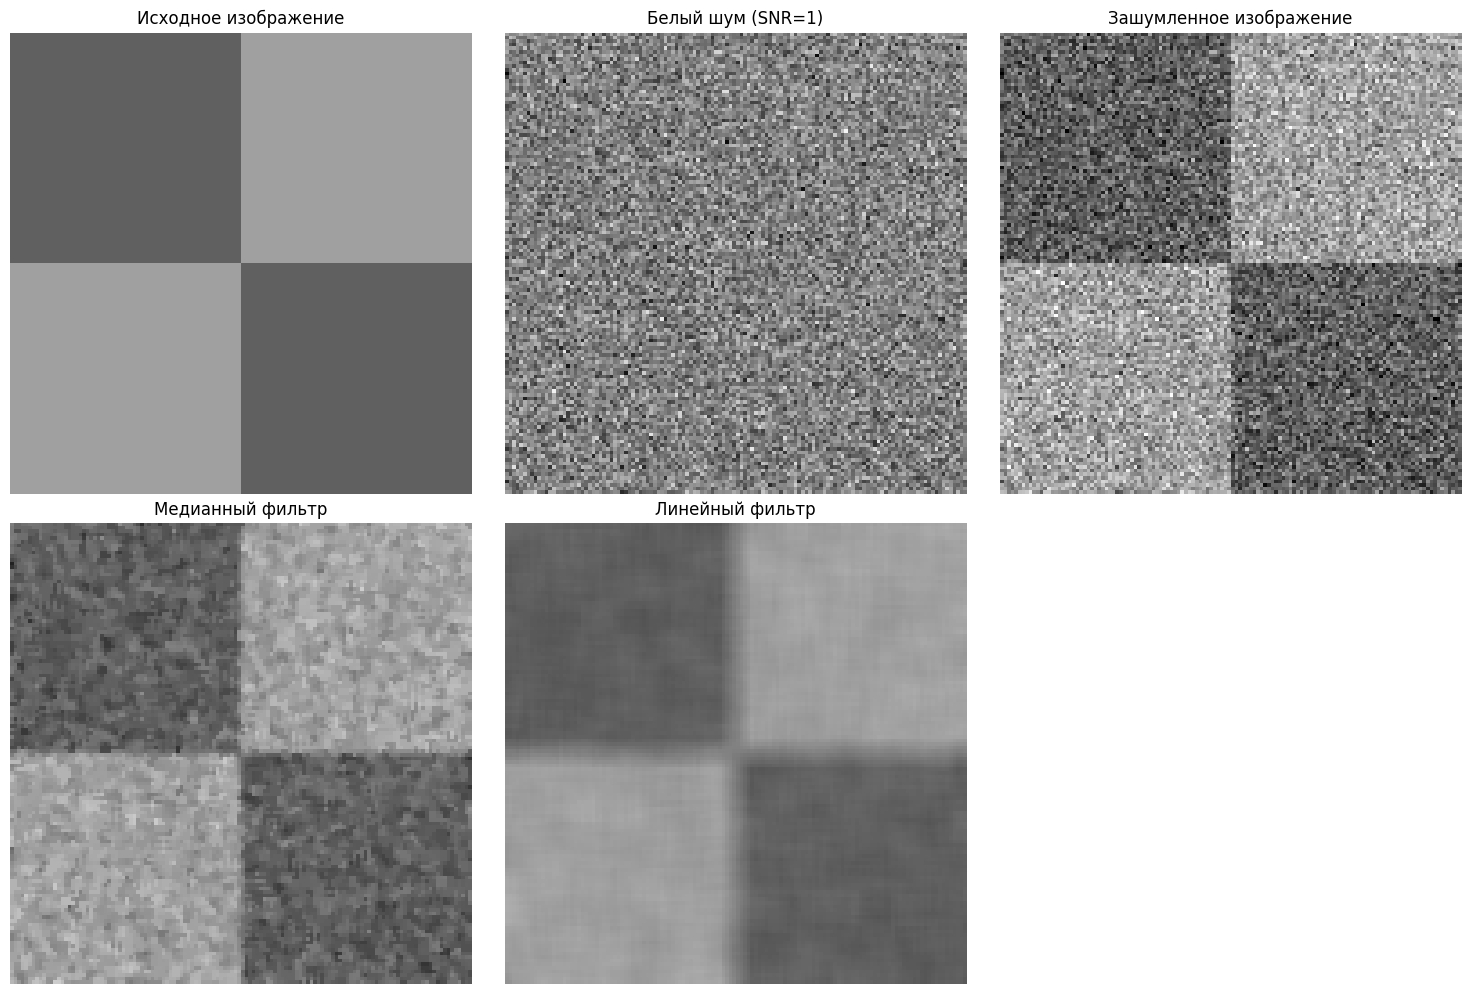


=== АДДИТИВНЫЙ БЕЛЫЙ ШУМ (SNR = 10) ===
Дисперсия исходного изображения: 1024.00
Дисперсия шума: 102.86
Дисперсия зашумленного изображения: 1130.49
Ср.Кв ошибка  зашумленного изображения: 103.15
Ср.Кв ошибка после линейной фильтрации: 26.89
Ср.Кв ошибка после медианной фильтрации: 19.97
Коэффициент снижения шума (линейный): 0.2607
Коэффициент снижения шума (медианный): 0.1937


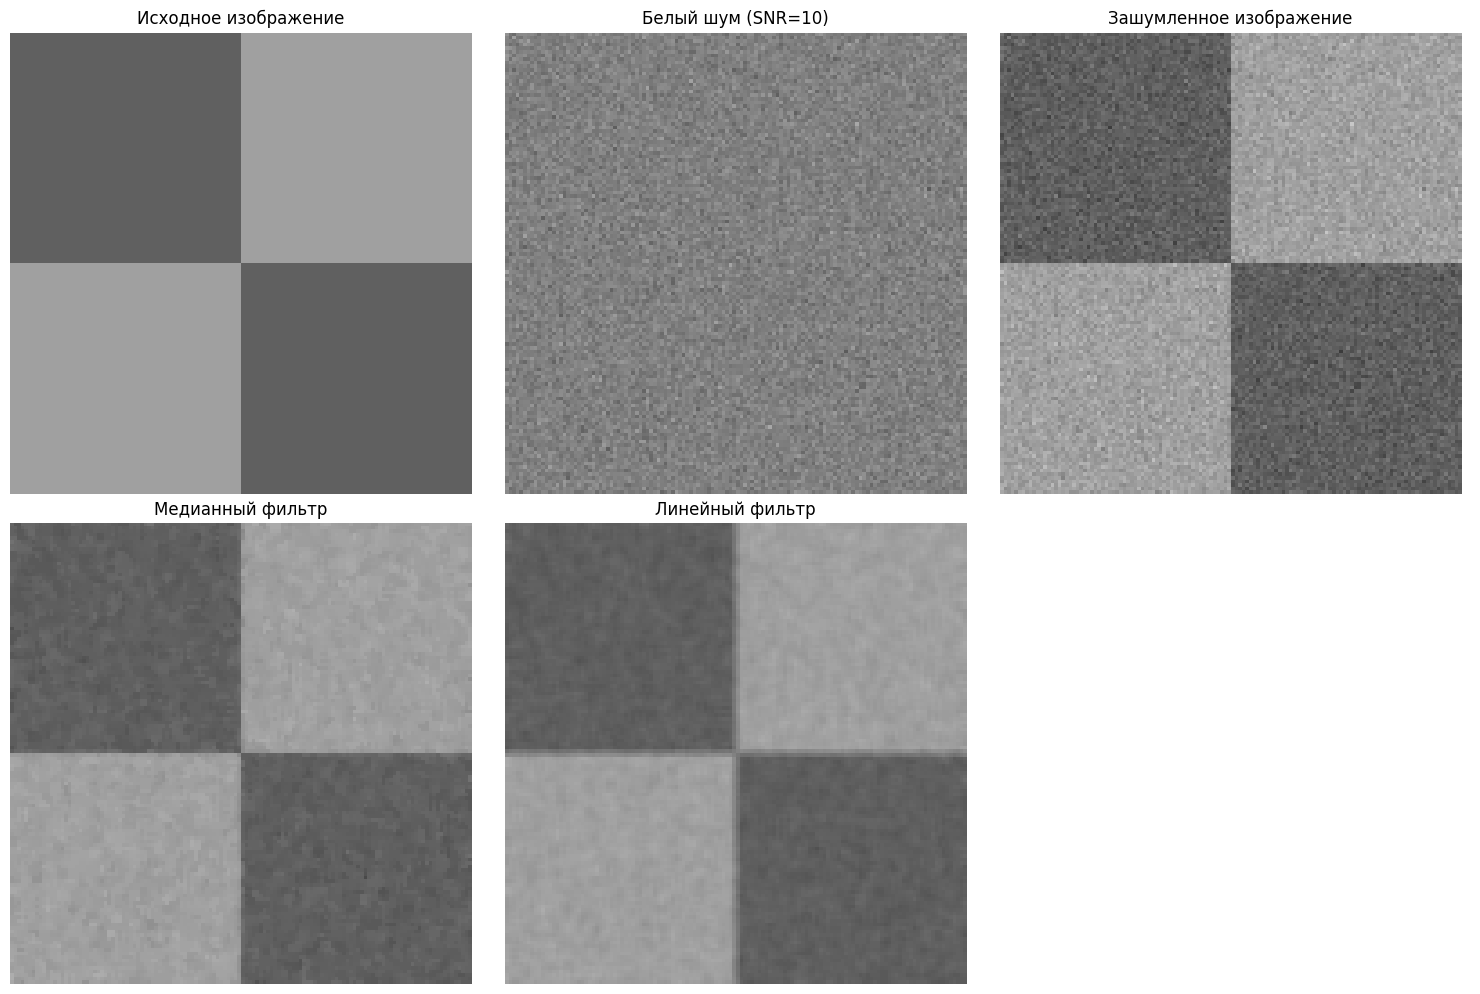


=== ИМПУЛЬСНЫЙ ШУМ (p = 0.1) ===
Дисперсия исходного изображения: 1024.00
Ср.Кв ошибка зашумленного изображения: 1755.41
Ср.Кв ошибка после линейной фильтрации: 226.09
Ср.Кв ошибка после медианной фильтрации: 4.80
Коэффициент снижения шума (линейный): 0.1288
Коэффициент снижения шума (медианный): 0.0027


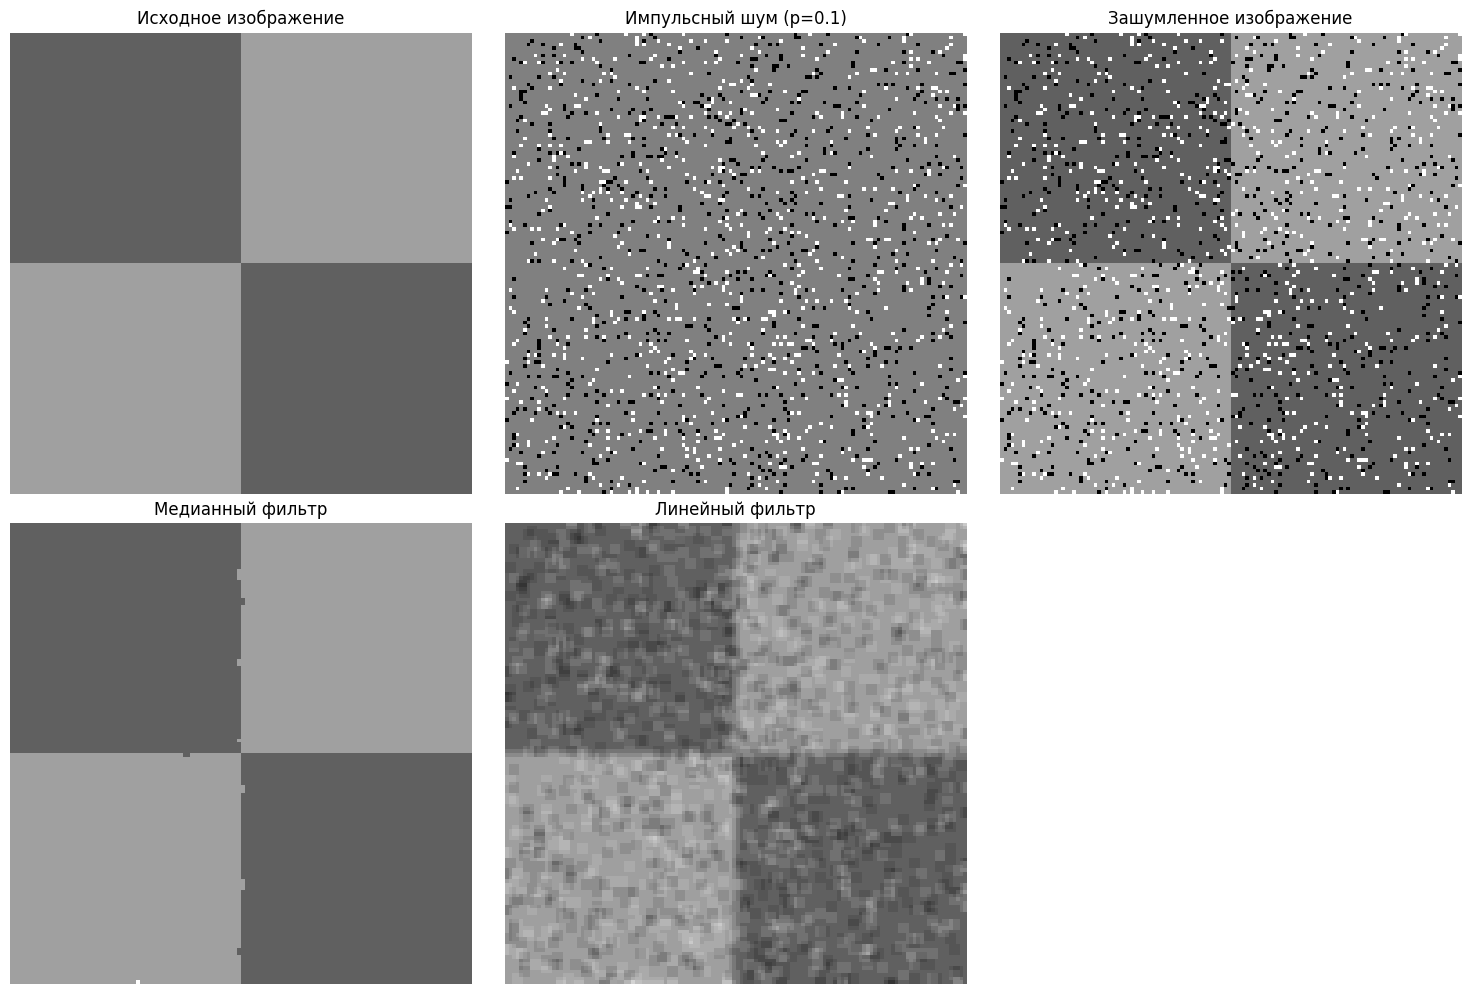


=== ИМПУЛЬСНЫЙ ШУМ (p = 0.3) ===
Дисперсия исходного изображения: 1024.00
Ср.Кв ошибка зашумленного изображения: 5139.19
Ср.Кв ошибка после линейной фильтрации: 227.90
Ср.Кв ошибка после медианной фильтрации: 20.75
Коэффициент снижения шума (линейный): 0.0443
Коэффициент снижения шума (медианный): 0.0040


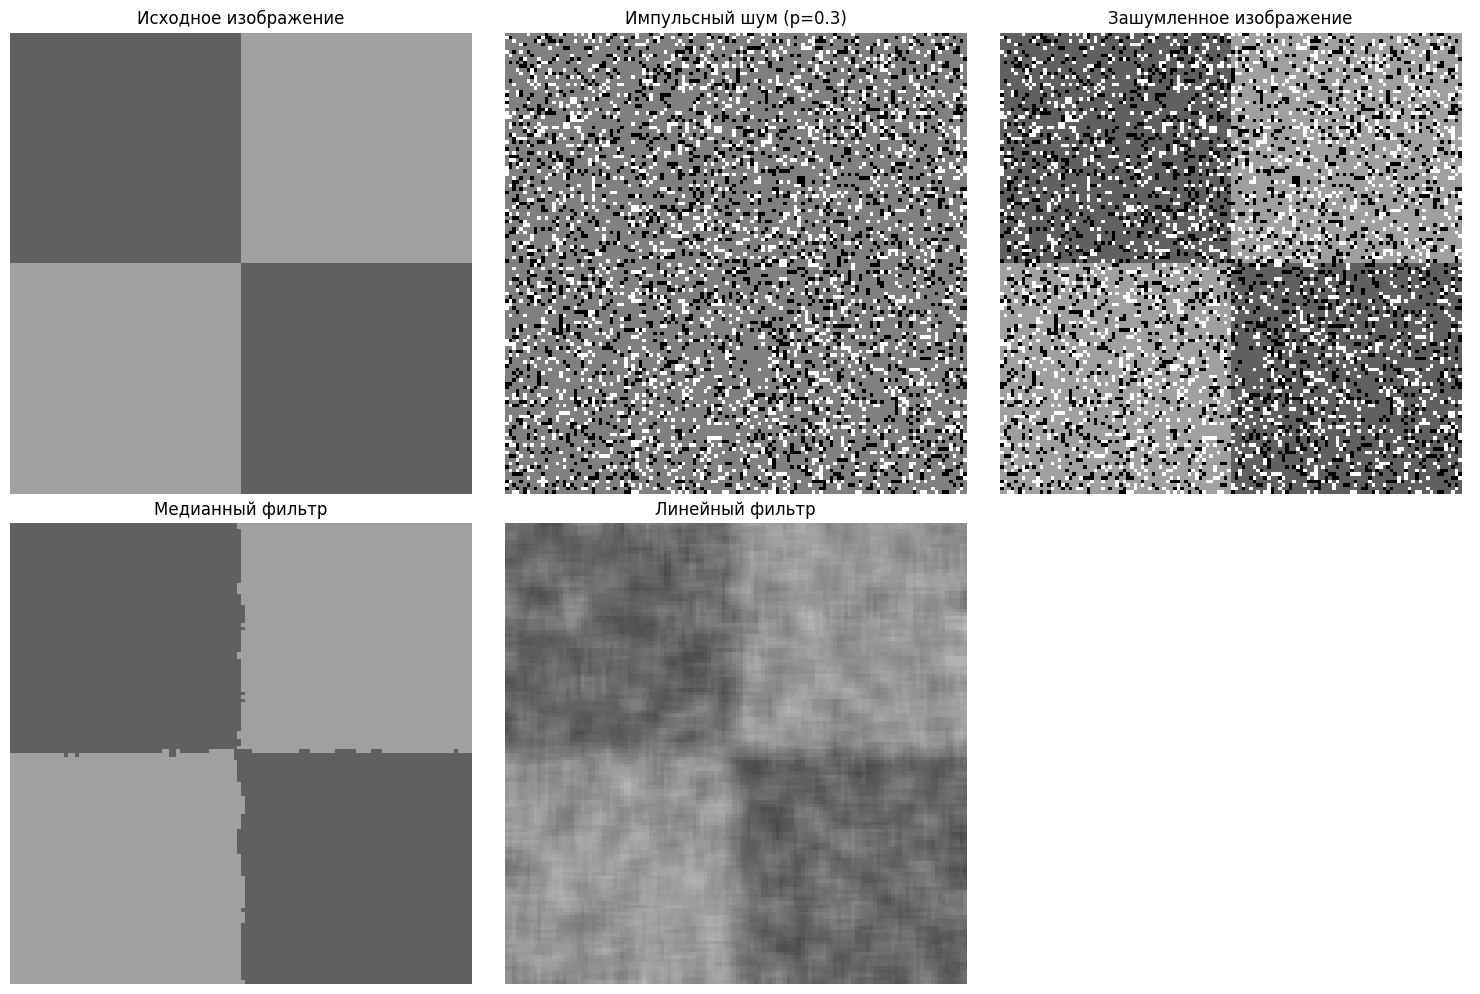

In [190]:
# Генерация шахматного поля
img_chessboard = generate_chessboard()

analyze_gaussian_noise(img_chessboard, 1, 9)
analyze_gaussian_noise(img_chessboard, 10, 3)
analyze_impulse_noise(img_chessboard,0.1, 3)
analyze_impulse_noise(img_chessboard,0.3, 7)